In [9]:
import pandas as pd, numpy as np, warnings; warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
from sklearn.model_selection import (train_test_split, cross_val_score, StratifiedKFold, learning_curve)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, roc_auc_score, f1_score, classification_report, ConfusionMatrixDisplay, RocCurveDisplay)
from xgboost import XGBClassifier
import shap, joblib

In [ ]:
df = pd.read_csv("sales & financial.csv")              
df = df.drop_duplicates().reset_index(drop=True)
df = df.drop(columns=["shop_id", "year_month"])        
X = df.drop(columns=["target_credit_ready"])
y = df["target_credit_ready"].astype(int)

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [13]:
imp = SimpleImputer(strategy="median")
def P(clf, scale=False):
    return Pipeline([("imp", imp)] + ([("sc", StandardScaler())] if scale else []) + [("clf", clf)])

models = {
 "LogisticRegression": P(LogisticRegression(max_iter=1000, class_weight="balanced"), scale=True),
 "DecisionTree":       P(DecisionTreeClassifier(max_depth=6, class_weight="balanced", random_state=42)),
 "RandomForest":       P(RandomForestClassifier(n_estimators=300, max_depth=10, class_weight="balanced", random_state=42)),
 "GradientBoosting":   P(GradientBoostingClassifier(random_state=42)),
 "XGBoost":            P(XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.08, subsample=0.9, eval_metric="logloss", random_state=42)),
}

In [14]:
print("=== 5-model comparison (CV ROC-AUC) ===")
cv_auc, cv_acc = {}, {}
for name, m in models.items():
    cv_auc[name] = cross_val_score(m, X_train, y_train, cv=cv, scoring="roc_auc").mean()
    cv_acc[name] = cross_val_score(m, X_train, y_train, cv=cv, scoring="accuracy").mean()
    print(f"  {name:20s} AUC {cv_auc[name]:.3f} | Acc {cv_acc[name]:.3f}")
best_name = max(cv_auc, key=cv_auc.get)
print("Best model:", best_name)
model = models[best_name]; model.fit(X_train, y_train)

=== 5-model comparison (CV ROC-AUC) ===
  LogisticRegression   AUC 0.884 | Acc 0.804
  DecisionTree         AUC 0.779 | Acc 0.726
  RandomForest         AUC 0.858 | Acc 0.775
  GradientBoosting     AUC 0.861 | Acc 0.775
  XGBoost              AUC 0.852 | Acc 0.764
Best model: LogisticRegression


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imp', ...), ('sc', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['months_active','monthly_revenue_rs','monthly_expenses_rs',..., 'credit_sales_ratio','digital_payment_ratio','stockout_rate']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace allocc

In [15]:
y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]
print("\nAccuracy:", round(accuracy_score(y_test, y_pred), 3))
print("ROC-AUC :", round(roc_auc_score(y_test, y_proba), 3))
print("F1      :", round(f1_score(y_test, y_pred), 3))
print(classification_report(y_test, y_pred, target_names=["not ready", "ready"]))


Accuracy: 0.828
ROC-AUC : 0.907
F1      : 0.824
              precision    recall  f1-score   support

   not ready       0.81      0.85      0.83       199
       ready       0.85      0.80      0.82       201

    accuracy                           0.83       400
   macro avg       0.83      0.83      0.83       400
weighted avg       0.83      0.83      0.83       400



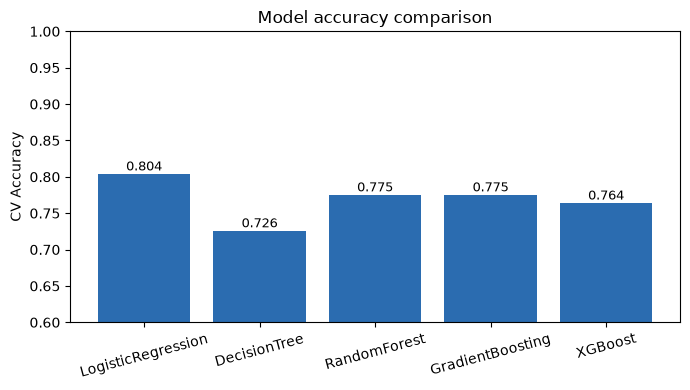

In [16]:
names = list(cv_acc); accs = [cv_acc[n] for n in names]
plt.figure(figsize=(7,4)); bars = plt.bar(names, accs, color="#2b6cb0")
for b, a in zip(bars, accs): plt.text(b.get_x()+b.get_width()/2, a+0.005, f"{a:.3f}", ha="center", fontsize=9)
plt.ylim(0.6, 1.0); plt.ylabel("CV Accuracy"); plt.title("Model accuracy comparison")
plt.xticks(rotation=15); plt.tight_layout(); plt.show()

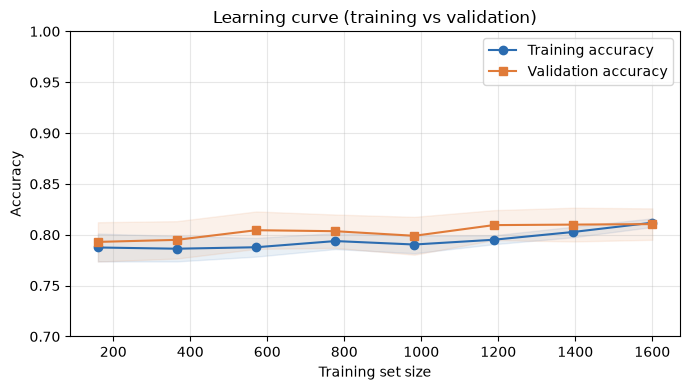

In [18]:
sizes, tr, val = learning_curve(model, X, y, cv=cv, scoring="accuracy", train_sizes=np.linspace(0.1, 1.0, 8), n_jobs=-1)
plt.figure(figsize=(7,4))
plt.plot(sizes, tr.mean(1),  "o-", label="Training accuracy",   color="#2b6cb0")
plt.plot(sizes, val.mean(1), "s-", label="Validation accuracy", color="#e07b39")
plt.fill_between(sizes, tr.mean(1)-tr.std(1),  tr.mean(1)+tr.std(1),  alpha=0.1, color="#2b6cb0")
plt.fill_between(sizes, val.mean(1)-val.std(1), val.mean(1)+val.std(1), alpha=0.1, color="#e07b39")
plt.xlabel("Training set size"); plt.ylabel("Accuracy"); plt.ylim(0.7, 1.0)
plt.title("Learning curve (training vs validation)"); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

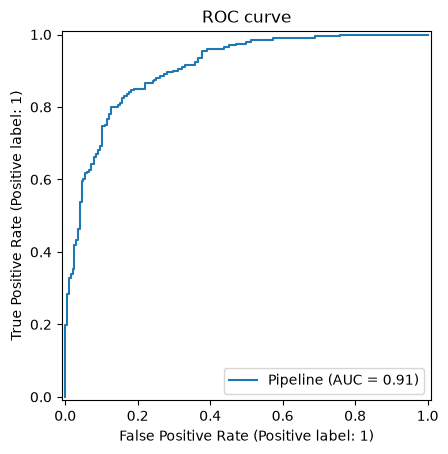

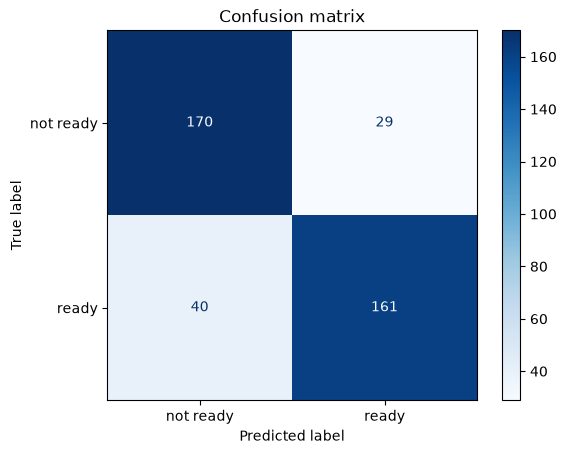

In [19]:
RocCurveDisplay.from_estimator(model, X_test, y_test); plt.title("ROC curve"); plt.show()
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test,
    display_labels=["not ready", "ready"], cmap="Blues"); plt.title("Confusion matrix"); plt.show()

Background dataset has 400 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=400 when initializing the masker.


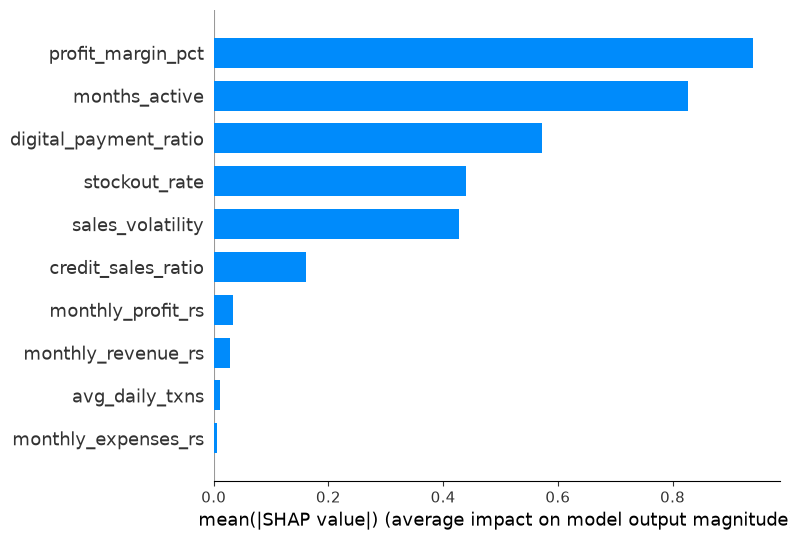

In [ ]:
clf = model.named_steps["clf"]
X_imp = pd.DataFrame(model.named_steps["imp"].transform(X_test), columns=X.columns)
if best_name in ["DecisionTree", "RandomForest", "GradientBoosting", "XGBoost"]:
    explainer = shap.TreeExplainer(clf); Xexp = X_imp.iloc[:1000]
else:  
    Xexp = pd.DataFrame(model.named_steps["sc"].transform(X_imp), columns=X.columns).iloc[:1000]
    explainer = shap.LinearExplainer(clf, Xexp)
shap_values = explainer.shap_values(Xexp)
shap.summary_plot(shap_values, Xexp, plot_type="bar", max_display=10)

In [21]:
i = 0
score = round(model.predict_proba(X_test.iloc[[i]])[0, 1] * 100)
print(f"\nCredit-readiness score: {score}/100",
      "-> READY" if score >= 50 else "-> NOT READY")
row = X_test.iloc[[i]].copy(); base = model.predict_proba(row)[0, 1]
cf = row.copy()
cf["profit_margin_pct"]    += 6
cf["digital_payment_ratio"] = min(0.6, cf["digital_payment_ratio"].iloc[0] + 0.15)
cf["stockout_rate"]         = max(0.0, cf["stockout_rate"].iloc[0] - 0.06)
new = model.predict_proba(cf)[0, 1]
print(f"After improvements: {base*100:.0f}/100 -> {new*100:.0f}/100")


Credit-readiness score: 59/100 -> READY
After improvements: 59/100 -> 97/100


In [22]:
joblib.dump(model, "component1_sales_financial_model.pkl")
print("\nSaved best model:", best_name)


Saved best model: LogisticRegression
